In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('wine_data.csv' ,header=None, usecols=[0,1,2])

In [4]:
df.columns=['class labels', 'Alcohol', 'Malic acid']

In [5]:
df

,class labels,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

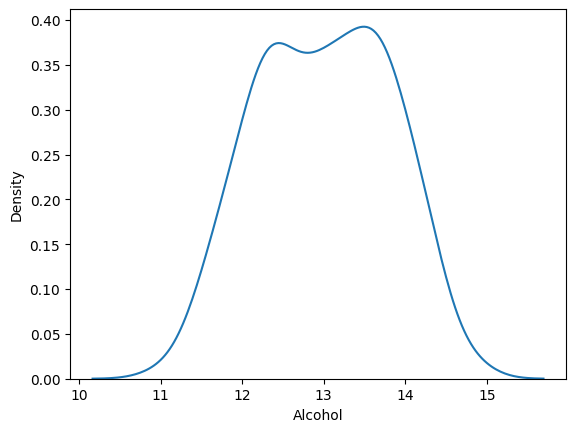

In [6]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

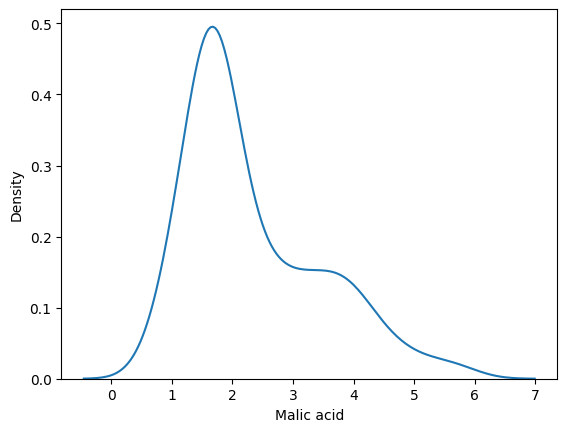

In [7]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

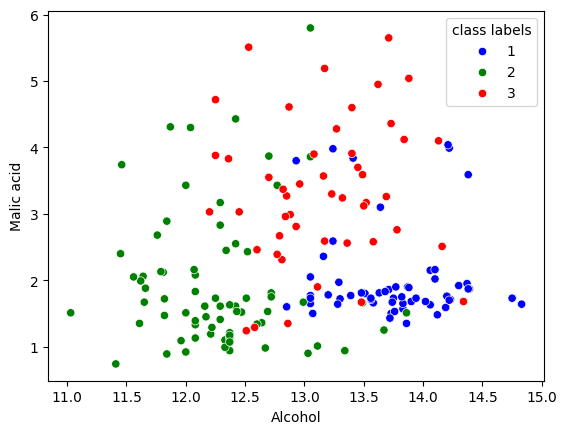

In [8]:
color_dict={1:'Blue', 2:'green',3:'red'}
sns.scatterplot(x=df['Alcohol'],y=df['Malic acid'],hue=df['class labels'],palette=color_dict)

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df[['Alcohol','Malic acid']],df['class labels'],test_size=0.3,random_state=0)

x_train.shape , x_test.shape

((124, 2), (54, 2))

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [16]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [17]:
np.round(x_train.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [18]:
np.round(x_train_scaled.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


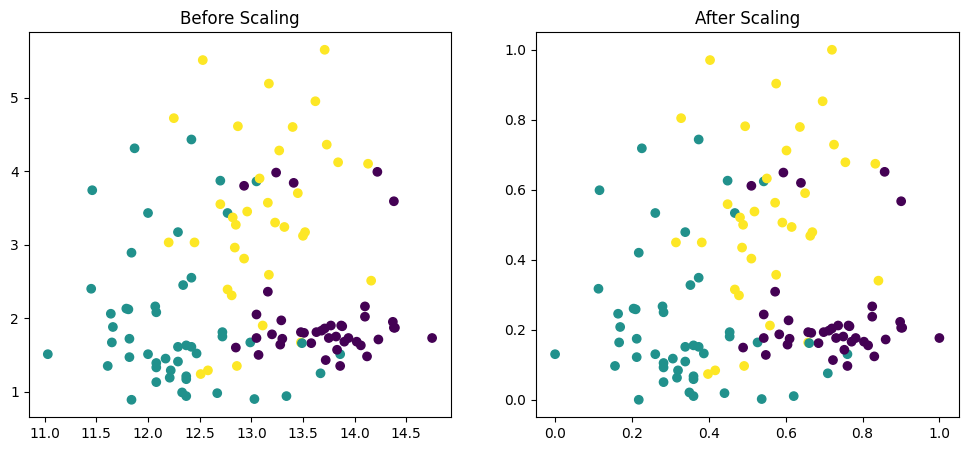

In [31]:
fig,(ax1,ax2) =plt.subplots(ncols = 2, figsize=(12,5))

ax1.scatter(x=x_train['Alcohol'],y=x_train['Malic acid'],c=y_train)
ax1.set_title("Before Scaling")

ax2.scatter(x=x_train_scaled['Alcohol'],y=x_train_scaled['Malic acid'],c=y_train)
ax2.set_title("After Scaling")

plt.show()

<Axes: title={'center': 'After SCaling'}, xlabel='Alcohol', ylabel='Density'>

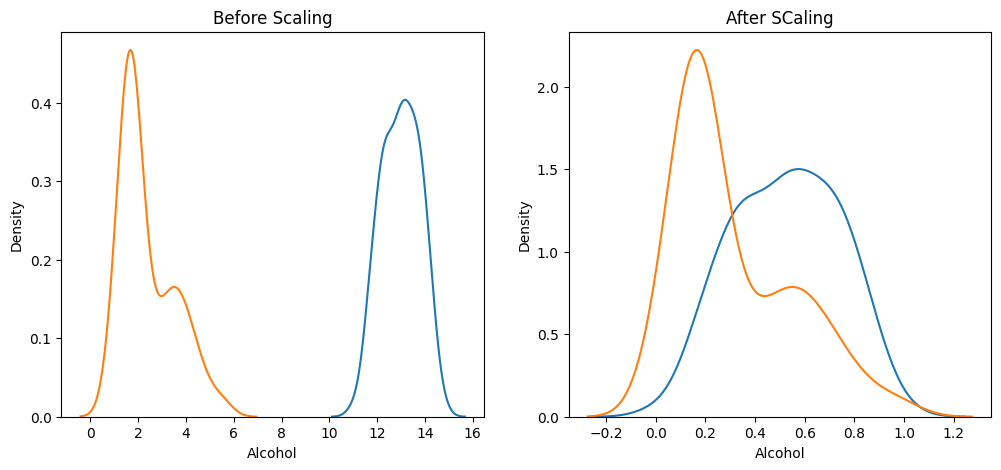

In [35]:
fig,(ax1, ax2) = plt.subplots(ncols=2 ,figsize=(12,5))

ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Alcohol'], ax = ax1)
sns.kdeplot(x_train['Malic acid'], ax = ax1)

ax2.set_title('After SCaling')
sns.kdeplot(x_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(x_train_scaled['Malic acid'], ax = ax2)